In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error

import joblib

In [3]:
data = pd.read_csv("climate_change_dataset.csv")

data.head()

,Year,Country,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%)
0,2006,UK,8.9,9.3,3.1,1441,530911230,20.4,14,59.8
1,2019,USA,31.0,4.8,4.2,2407,107364344,49.2,8,31.0
2,2014,France,33.9,2.8,2.2,1241,441101758,33.3,9,35.5
3,2010,Argentina,5.9,1.8,3.2,1892,1069669579,23.7,7,17.7
4,2007,Germany,26.9,5.6,2.4,1743,124079175,12.5,4,17.4


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Year                         1000 non-null   int64  
 1   Country                      1000 non-null   str    
 2   Avg Temperature (°C)         1000 non-null   float64
 3   CO2 Emissions (Tons/Capita)  1000 non-null   float64
 4   Sea Level Rise (mm)          1000 non-null   float64
 5   Rainfall (mm)                1000 non-null   int64  
 6   Population                   1000 non-null   int64  
 7   Renewable Energy (%)         1000 non-null   float64
 8   Extreme Weather Events       1000 non-null   int64  
 9   Forest Area (%)              1000 non-null   float64
dtypes: float64(5), int64(4), str(1)
memory usage: 78.3 KB


In [5]:
data.rename(columns={
    'Avg Temperature (°C)': 'Avg_Temp',
    'CO2 Emissions (Tons/Capita)': 'CO2',
    'Sea Level Rise (mm)': 'Sea_Level',
    'Rainfall (mm)': 'Rainfall',
    'Renewable Energy (%)': 'Renewable',
    'Extreme Weather Events': 'Extreme_Weather',
    'Forest Area (%)': 'Forest'
}, inplace=True)

In [6]:
data.isnull().sum()

Year               0
Country            0
Avg_Temp           0
CO2                0
Sea_Level          0
Rainfall           0
Population         0
Renewable          0
Extreme_Weather    0
Forest             0
dtype: int64

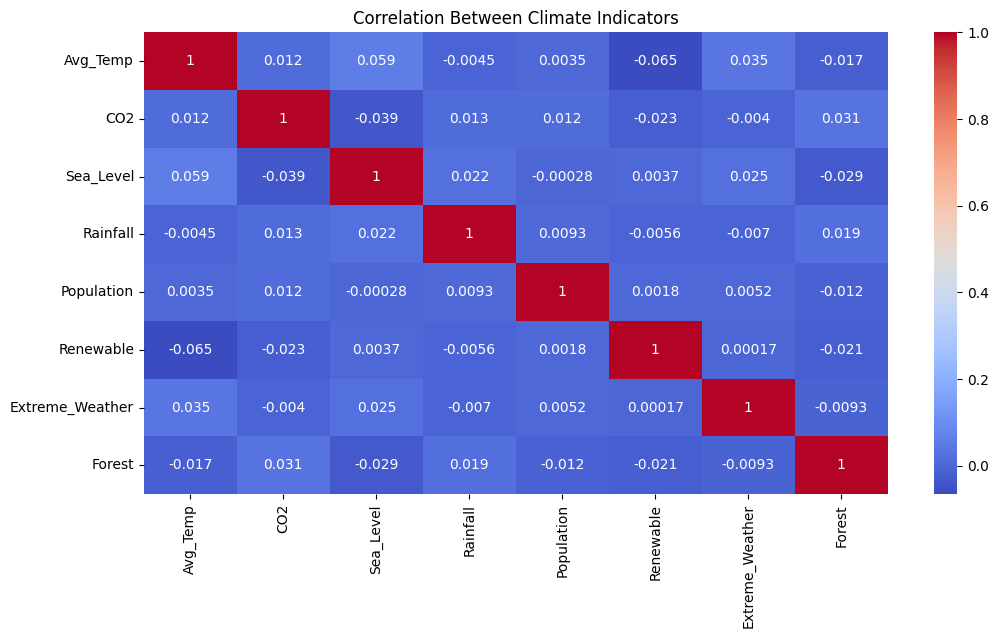

In [7]:
features = ['Avg_Temp','CO2','Sea_Level','Rainfall','Population','Renewable','Extreme_Weather','Forest']

plt.figure(figsize=(12,6))
sns.heatmap(data[features].corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Between Climate Indicators")
plt.show()

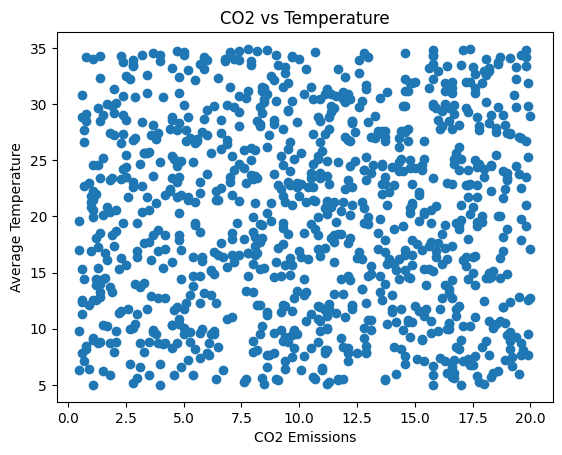

In [ ]:
plt.scatter(data['CO2'], data['Avg_Temp'])

plt.xlabel("CO2 Emissions")
plt.ylabel("Average Temperature")

plt.title("CO2 vs Temperature")

plt.show()



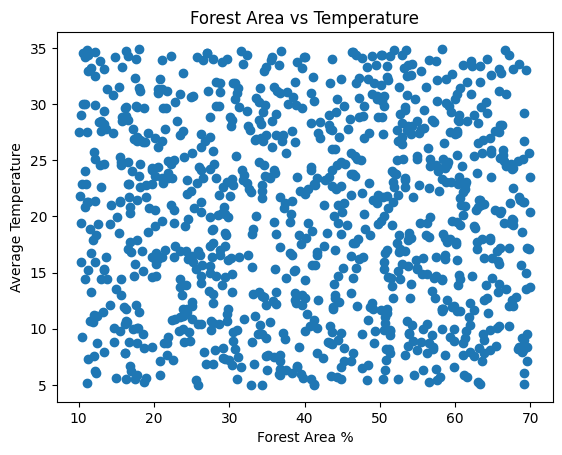

In [9]:
plt.scatter(data['Forest'], data['Avg_Temp'])

plt.xlabel("Forest Area %")
plt.ylabel("Average Temperature")

plt.title("Forest Area vs Temperature")

plt.show()

In [10]:
X = data[['CO2','Sea_Level','Rainfall','Population','Renewable','Extreme_Weather','Forest']]

y = data['Avg_Temp']

In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
# Selecting train and test data

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
# Linear regression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

train_mse_lr = mean_squared_error(y_train, y_train_pred)
test_mse_lr = mean_squared_error(y_test, y_test_pred)

print("Linear regression train MSE:", train_mse_lr)
print("Linear regression test MSE:", test_mse_lr)

Linear Regression Train MSE: 73.18567575052802
Linear Regression Test MSE: 68.61591634701412


In [17]:
# Decision tree


dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

test_mse_dt = mean_squared_error(y_test, y_pred_dt)

print("Decision Tree Test MSE:", test_mse_dt)

Decision Tree Test MSE: 134.47485


In [19]:
# Random forest

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

test_mse_rf = mean_squared_error(y_test, y_pred_rf)

print("Random Forest Test MSE:", test_mse_rf)

Random Forest Test MSE: 76.356323445


In [41]:
sgd_model = SGDRegressor(max_iter=100, learning_rate='constant', eta0=0.01)

sgd_model.fit(X_train, y_train)

y_pred_sgd = sgd_model.predict(X_test)

test_mse_sgd = mean_squared_error(y_test, y_pred_sgd)

print("SGD Regression Test MSE:", test_mse_sgd)

SGD Regression Test MSE: 71.35597213123171


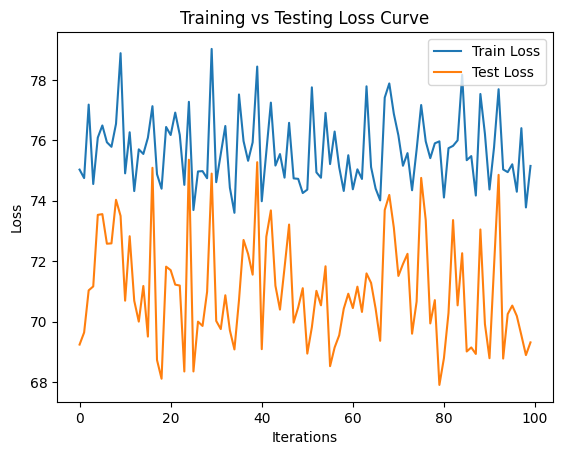

In [54]:
train_errors = []
test_errors = []

sgd = SGDRegressor(max_iter=1, warm_start=True, learning_rate='constant', eta0=0.01, tol=None)

for i in range(100):
    sgd.fit(X_train, y_train)

    train_pred = sgd.predict(X_train)
    test_pred = sgd.predict(X_test)

    train_errors.append(mean_squared_error(y_train, train_pred))
    test_errors.append(mean_squared_error(y_test, test_pred))

plt.plot(train_errors, label="Train Loss")
plt.plot(test_errors, label="Test Loss")

plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.title("Training vs Testing Loss Curve")

plt.legend()

plt.show()

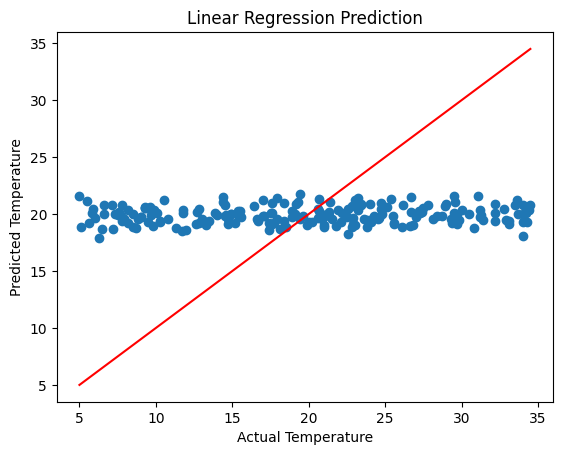

In [ ]:
plt.scatter(y_test, y_test_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")

plt.title("Linear Regression Prediction")

plt.show()

In [47]:
mse_scores = {
    "LinearRegression": test_mse_lr,
    "DecisionTree": test_mse_dt,
    "RandomForest": test_mse_rf,
    "SGDRegression": test_mse_sgd
}

best_model_name = min(mse_scores, key=mse_scores.get)

print("Best Model:", best_model_name)

Best Model: LinearRegression


In [ ]:
if best_model_name == "LinearRegression":
    best_model = lr_model
elif best_model_name == "DecisionTree":
    best_model = dt_model
elif best_model_name == "RandomForest":
    best_model = rf_model
else:
    best_model = sgd_model

joblib.dump(best_model, "best_climate_model.pkl")

print("Best model saved.")

Best model saved.


In [59]:
loaded_model = joblib.load("best_climate_model.pkl")

sample = X_test[0].reshape(1,-1)

prediction = loaded_model.predict(sample)

print("Predicted Temperature:", prediction[0])

Predicted Temperature: 19.579972778486074
